In [105]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
!pip install arch
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

# §1 イントロダクション
### 概要
§2ではJPX日経400ETFの対数リターンが幾何ブラウン運動に従うと仮定して、そのボラティリティトをMLEを用いて推定する。§3では、§2におけるボラティリティが定数であるという制約では捉えきれない、ボラティリティクラスタリングも考慮した分析をするため、GARCHを用いた分析をする。その際、比較対象としてARCH、EGARCHを用いた分析をする。またこのセクションの分析方法は『Analysis of Financial Time Series』(Ruey S. Tsay著)の3章「Conditional Heteroscedastic Models」で述べられている分析方法のもとに行われる。Appendixでは、分析手法に関わる数理的背景について簡潔にまとめている。

### 本Notebookの目的と動機:
- 目的: JPX日経400のボラティリティ推定、統計的手法の比較とVaRへの応用
- 動機: 金融データに関する時系列分析を勉強する上で、ボラティリティに対して学習したことを応用してみたいと思ったため。

### 使用するデータ
- iShares JPX-Nikkei 400 ETF(1364.T)　(2001-01-01~2025-01-01)


# §2 GBMモデルーMLEによるドリフトとボラティリティの推定
### 概要
このセクションでは、iShares JPX-Nikkei 400 ETF(1364.T)の推移が幾何ブラウン運動に従うと仮定し、そのドリフトとボラティリティを最尤推定法を用いて推測する。

つまり、$S_t$を日経400ETFの値とし、それが以下の確率微分方程式
$$dS_t = \mu s_t dt + \sigma S_t dW(t)$$
に従うとし(ここで$W(t)$はブラウン運動)、$\mu, \sigma$をMLEを用いて推定する。

### §2.1 MLEによるドリフトとボラティリティの推定
MLEの導出についてはAppendix Bでその数理的背景を載せている。

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

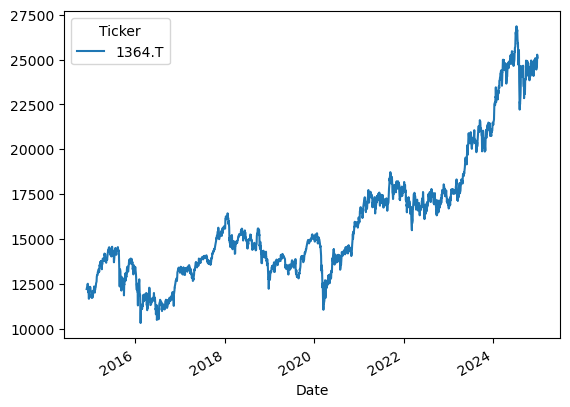

In [59]:
# データの取得
data = yf.download('1364.T', start='2001-01-01', end='2025-01-01', auto_adjust=True)

data['Close'].plot()

In [60]:
# 対数リターン
data_stats = pd.DataFrame(index=data.index)
data_stats['LogReturn'] = np.log(data['Close']/data['Close'].shift(1))

# パラメータの準備
log_returns = data_stats['LogReturn'].dropna()
n = len(log_returns)

# 最尤推定量の計算
hat_nu = log_returns.sum() / n
hat_sigma_sq = ((log_returns - hat_nu)**2).sum()/n
hat_sigma = np.sqrt(hat_sigma_sq)
hat_mu = hat_nu + 0.5 * hat_sigma_sq

print(f'hat_nu     （日時): {hat_nu:.6f}')
print(f'hat_sigma^2（日時): {hat_sigma_sq:.6f}')
print(f'hat_mu     （日時): {hat_mu:.6f}')

# 年率換算(営業日252日想定）
print(f'hat_sigma  （年率): {hat_sigma*np.sqrt(252):.6f}')
print(f'hat_mu     （年率): {hat_mu*252:.6f}')

hat_nu     （日時): 0.000290
hat_sigma^2（日時): 0.000136
hat_mu     （日時): 0.000358
hat_sigma  （年率): 0.185300
hat_mu     （年率): 0.090337


### §2.2 推定量を用いたGBMのパスのシミュレーション
§2.1で得られたドリフトとボラティリティを用いて、GBMのパスをシミュレーションする。

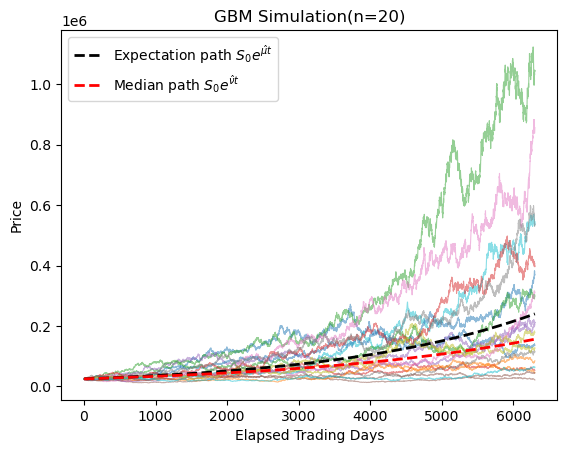

In [61]:
np.random.seed(42)

S0 = data['Close'].iloc[-1].item()
T_days = 252 * 25
n_paths = 20

dt = 1
t = np.arange(0, T_days + 1)

# 各パスについて、日時のブラウン運動増分　W_i - W_{i-1} ~ N(0, dt) を生成
dW = np.random.normal(loc=0, scale=np.sqrt(dt), size=(n_paths, T_days))
W = np.cumsum(dW, axis = 1)
W = np.hstack([np.zeros((n_paths, 1)), W]) #W_0 = 0 を先頭に追加

# GBMの解を適用
S_paths = S0 * np.exp(hat_nu * t + hat_sigma * W)

#　可視化
for i in range(n_paths):
    plt.plot(t, S_paths[i], alpha=0.5, lw=0.8)

# 期待値パスと中央値パス
plt.plot(t, S0 * np.exp(hat_mu * t), 'k--', lw=2, label=r'Expectation path $S_0 e^{\hat{\mu} t}$')
plt.plot(t, S0 * np.exp(hat_nu * t), 'r--', lw=2, label=r'Median path $S_0 e^{\hat{\nu} t}$')

plt.title(f'GBM Simulation(n={n_paths})')
plt.xlabel('Elapsed Trading Days')
plt.ylabel('Price')
plt.legend()

§2では、GBMモデルのもとで、対数リターンのドリフト$\mu$とボラティリティ$\sigma$を、ともに時間に依存しない定数としてMLEを用いて推定した。しかし、この制約には限界がある。GBMは$\sigma$が全期間にわたって一定であることを仮定しているが、実際の株価データにおいてはボラティリティクラスタリング(大きいボラティリティの後には大きいボラティリティが続く）が観察されることが知られている（§3のACF分析で実証する)。§3ではこのボラティリティクラスタリングを捉えるためにGARCHモデルを導入する。


# §3 ARCH/GARCHモデルによるボラティリティ推定

### 概要
§2ではGBMを用い、ドリフト$\mu$とボラティリティ$\sigma$を観測期間全体で一定の
定数としてMLE推定した。しかし、この定式化を採用する前に、$\mu$と$\sigma$それぞれ
について、本当に定数として扱ってよいかを検証する必要がある。

Tsay (2005)は、対数リターン$r_t$の条件付き平均$\mu_t$と条件付き分散$\sigma_t^2$を
$$
\mu_t = E(r_t\mid\mathcal{F}_{t-1}), \qquad \sigma_t^2=\text{Var}(r_t\mid\mathcal{F}_{t-1})
$$
と定義した上で、実証的に「株式リターン$r_t$の系列相関は、あってもごく弱い」ことを
指摘している。以下では、この主張をJPX日経400のデータで検証し、$\mu_t$を単純な
定数$\phi_0$として扱えるかどうかを確認した上で、$\sigma_t^2$の時間変化(ボラティリティ
クラスタリング)を捉えるARCH/GARCH型のモデルを導入する。

### 分析の流れ

以下の分析は、Tsay (2005)『Analysis of Financial Time Series』第3章で提示されて
いる、条件付き分散モデルの標準的な分析手順に基づいて進める(Tsay, 2005, p.101)。
この手順は概ね以下の4段階から構成される。

1. **平均方程式の特定**:データの系列依存性を検定し、必要であれば(ARMAモデル等の)
   計量経済モデルを構築して、線形の依存性を取り除く
2. **ARCH効果の検定**:平均方程式の残差を用いて、ARCH効果の有無を検定する
3. **ボラティリティモデルの特定・同時推定**:ARCH効果が統計的に有意であれば、
   ボラティリティモデルを特定し、平均方程式とボラティリティ方程式の同時推定を行う
4. **モデル診断**:推定されたモデルを慎重に検証し、必要であれば精緻化する

以下、§3.1〜§3.4はこの4段階に対応している。

### §3.1 平均方程式の特定
対数リターン$r_t$、その絶対値$|r_t|$、二乗$r_t^2$のACF/PACFをプロットし、
Ljung-Box検定を用いて系列相関の有無を検証する。

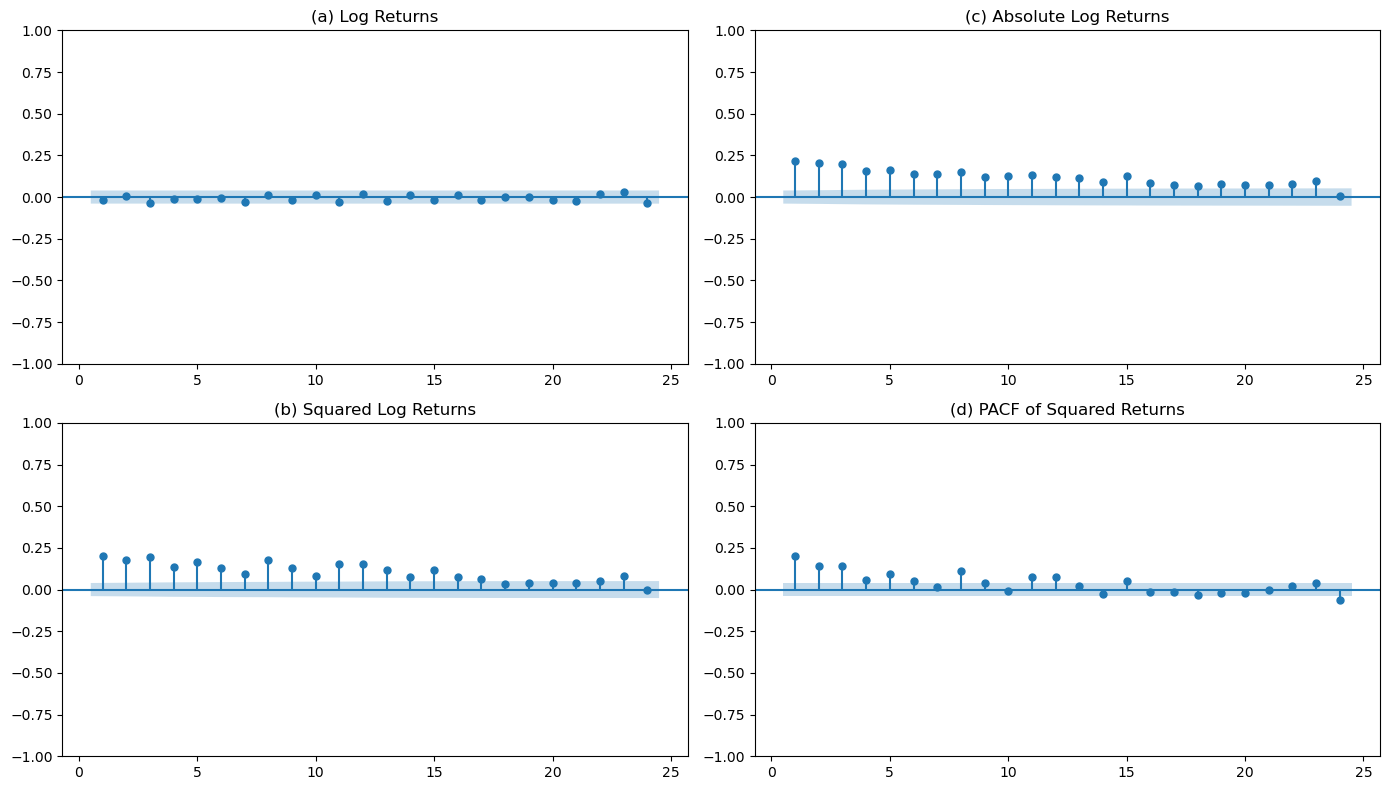

In [118]:
# =========================================
# ACF/PACFプロット(r_t, |r_t|, r_t^2)
# Ljung-Box検定(r_t自体）-> 系列相関の有無を確認
# =========================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(log_returns, lags=24, ax=axes[0,0],zero=False)
axes[0,0].set_title('(a) Log Returns')

plot_acf(log_returns.abs(), lags=24, ax=axes[0,1],zero=False)
axes[0,1].set_title('(c) Absolute Log Returns')

plot_acf(log_returns**2, lags=24, ax=axes[1,0],zero=False)
axes[1,0].set_title('(b) Squared Log Returns')

plot_pacf(log_returns**2, lags=24, ax=axes[1,1],zero=False)
axes[1,1].set_title('(d) PACF of Squared Returns')

plt.tight_layout()
plt.show()

In [124]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box検定(r_t自体）-> 系列相関の有無を確認
lb_r = acorr_ljungbox(log_returns, lags=[12], return_df=True)
print("Ljung-Box on r_t:\n", lb_r)

Ljung-Box on r_t:
       lb_stat  lb_pvalue
12  11.107274   0.519748


- ACF/PACFプロット

  $r_t$自体のACFは、ほぼ全てのラグで信頼区間内に収まっており、視覚的に系列相関がないことが確認できる。一方、$|r_t|$と$r_t^2$のACFは、長いラグまで緩やかに減衰しながら有意な正の値を示しており、ボラティリティクラスタリングの存在を示唆している。

- LjungBox検定

  Ljung-Box検定の結果、$r_t$に対しては$Q(12)=11.11$($p=0.52$)となり、5%水準、10%水準でも系列相関なしという帰無仮説を棄却できない。これはTsay (2005)が指摘する「株式リターンの系列相関は弱い」という一般的傾向と整合的である。

- 結論

  $r_t$自体には有意な系列相関が見られないため、平均方程式は$\mu_t=\phi_0$(定数項のみ)として十分であると判断し、以降の分析では$a_t=r_t-\hat\phi_0$($\hat\phi_0$は$r_t$の標本平均)を残差として用いる。


### §3.2 ARCH効果の検定
残差$a_t$に対してLM検定、$a_t^2$に対するLjung-Box検定(McLeod-Li検定)を実施する。

In [119]:
# 残差 a_t = r_t - mu_tを計算
a_t = log_returns - log_returns.mean()

# LM検定
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(a_t, nlags=12)

print(f"LM統計量: {lm_stat:.4f}, p値: {lm_pvalue:.6f}")
print(f"F統計量: {f_stat:.4f}, p値: {f_pvalue:.6f}")

# Ljung-Box検定(a_t^2に対して, McLeaod-Li版)
lb_r2 = acorr_ljungbox(a_t**2, lags=[12], return_df=True)
print("Ljung-Box(r_t^2) (McLeod-Li):\n", lb_r2)

LM統計量: 290.9119, p値: 0.000000
F統計量: 27.3288, p値: 0.000000
Ljung-Box(r_t^2) (McLeod-Li):
       lb_stat      lb_pvalue
12  711.79745  1.314394e-144


- 考察

  両検定とも、ARCH効果なしという帰無仮説を強く棄却しており、$a_t^2$には強いボラティリティクラスタリングが存在することが統計的に確認された。

- 結果
  
  ARCH効果が統計的に有意であるため、Tsayの分析手順に従い、ボラティリティモデルの特定・推定に進む。

### §3.3 ボラティリティモデルの特定
Tsay(2005)ではARCHの次元の決定においてはPACFを用いることが述べられている。上記のPACFにおいてはラグ3程度で信頼区間内に収まっているように見えるが、他の次元も試し、情報量基準で比較する。同時にGARCH(1,1), EGARCH(1,1)モデルを構築し、情報量基準で比較する。

In [120]:
# ARCH(m)モデルをフィット
arch_models = {}
for m in [1, 3, 5, 9, 12, 15, 20]:
    am = arch_model(a_t, vol='ARCH', p=m, mean='Zero', dist='normal')
    arch_models[f'ARCH({m})'] = am.fit(disp='off')

# GARCH(1, 1)をフィット
garch_model = arch_model(a_t, vol='Garch', p=1, q=1, mean='Zero', dist='normal')
arch_models['GARCH(1,1)'] = garch_model.fit(disp='off')

# EGARCH(1, 1)をフィット
egarch_model = arch_model(a_t, vol='EGARCH', p=1, q=1, mean='Zero', dist='normal')
arch_models['EGARCH(1,1)'] = egarch_model.fit(disp='off')

# AIC/BICで比較
comparison = pd.DataFrame({
    name: {'AIC':res.aic, 'BIC': res.bic, 'LogLik': res.loglikelihood, 'Params': res.num_params} for name, res in arch_models.items()
}).T
print(comparison.sort_values('BIC'))



                      AIC           BIC       LogLik  Params
GARCH(1,1)  -15577.963010 -15560.507719  7791.981505     3.0
EGARCH(1,1) -15558.761866 -15541.306575  7782.380933     3.0
ARCH(9)     -15556.255029 -15498.070726  7788.127514    10.0
ARCH(5)     -15529.450517 -15494.539935  7770.725259     6.0
ARCH(15)    -15574.420192 -15481.325307  7803.210096    16.0
ARCH(3)     -15472.639186 -15449.365464  7740.319593     4.0
ARCH(12)    -15495.752780 -15420.113186  7760.876390    13.0
ARCH(20)    -15531.772391 -15409.585355  7786.886196    21.0
ARCH(1)     -15267.644180 -15256.007319  7635.822090     2.0


/opt/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001363. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001363. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/lib/python3.13/site-packages/arch/uni

まずARCH(m)モデルを複数の次数($m=1,3,5,9,12,15,20$)で構築し、GARCH(1,1)、EGARCH(1,1)を構築、それらをAIC/BICで比較すると、ARCH(m)モデルでは$m=9$でBIC基準が最良となった。GARCH(1,1)では、わずか3パラメータで、ARCH(m)モデルを、AIC・BICともに上回った。

以降、GARCH(1,1)を暫定的な最良モデルとして、§3.4でその適合度を診断する。

### §3.4 モデル診断
暫定モデルGARCH(1,1)について、標準化残差$\hat{a}_t = \frac{a_t}{\sigma_t}$を計算し、$a_t$、$a_t^2$対するLjung-Box検定を実施し、歪度・尖度、QQプロット分析を実施する。

Ljung-Box on standardized residuals:
      lb_stat  lb_pvalue
12  3.956542   0.984208
Ljung-Box on squared standardized residuals:
      lb_stat  lb_pvalue
12  4.528935   0.971895
歪度: -0.3700777379313722:.4f
尖度: 4.4997


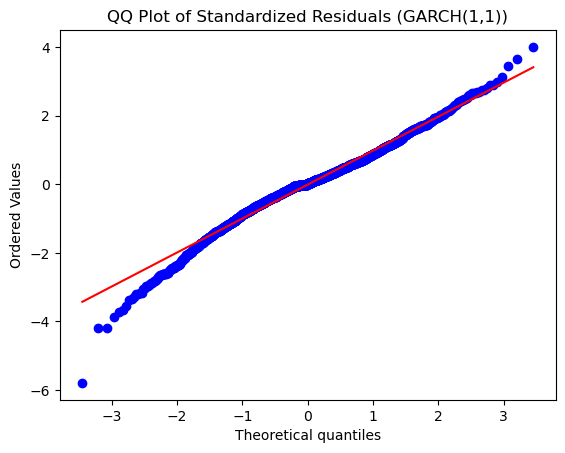

In [108]:
# ステップ4: モデル診断
# ===========================================
# 標準化残差 a_t/σ_t　を計算
garch_res = arch_models['GARCH(1,1)']
std_resid = garch_res.resid / garch_res.conditional_volatility

# Ljung-Box(標準化残差自体)-> 平均モデルの妥当性再確認
lb_resid = acorr_ljungbox(std_resid, lags=[12], return_df=True)
print("Ljung-Box on standardized residuals:\n", lb_resid)

# Ljung-Box(標準化残差の二乗) -> ARCH効果が消えたか確認
lb_resid_sq = acorr_ljungbox( std_resid**2, lags=[12], return_df=True)
print("Ljung-Box on squared standardized residuals:\n", lb_resid_sq)

# 歪度・尖度・QQプロット ->　分布仮定の妥当性確認
print(f"歪度: {stats.skew(std_resid):.4f}")
print(f"尖度: {stats.kurtosis(std_resid, fisher=False):.4f}")

stats.probplot(std_resid, dist="norm", plot=plt)
plt.title("QQ Plot of Standardized Residuals (GARCH(1,1))")
plt.show()

平均方程式・ボラティリティ方程式の診断はともに良好である。特に、§3.2で$a_t^2$に確認された強いARCH効果($Q(12)=711.80$, $p\approx0$)は、モデル適合後には$p=0.972$まで解消されており、GARCH(1,1)がボラティリティクラスタリングをほぼ完全に吸収できたことが分かる。

一方、尖度$4.50$は正規分布の基準値$3$を明確に上回っている。QQプロット(下図)でも、中央部分は理論直線に沿っているものの、両端(特に下方向)で顕著な逸脱が見られる。

これは、時間変化するボラティリティを考慮した後でもなお、実際のリターン分布が正規分布より厚い裾(fat tail)を持つことを示している。すなわち、**誤差項$\varepsilon_t$に正規分布を仮定したことが不適切であった**と判断できる。

**結論**:平均構造・ボラティリティ構造の診断は良好である一方、分布の仮定に問題が残っている。Tsay (2005)の分析手順のステップ4「必要であれば精緻化する」に従い、誤差項の分布を再検討する(§3.3')。

### §3.3' ボラティリティモデルの再特定(分布の見直し)

§3.4の診断結果を受け、誤差項の分布をStudent-t分布、および歪みStudent-t分布に
変更し、GARCH(1,1)(誤差項の分布を標準正規分布と仮定)と合わせて再度AIC/BICで比較する。


In [121]:
# GARCH(1, 1), 分布をStudent-t分布に変更
garch_t = arch_model(a_t, vol='Garch', p=1, q=1, mean='Zero', dist='t')
arch_models['GARCH(1,1)_t'] = garch_t.fit(disp='off')

# GARCH(1, 1), 分布を歪みStudent-t分布に変更
garch_skewt = arch_model(a_t, vol='Garch', p=1, q=1, mean='Zero', dist='skewt')
arch_models['GARCH(1,1)_skewt'] = garch_skewt.fit(disp='off')


comparison = pd.DataFrame({
    name: {'AIC':res.aic, 'BIC': res.bic, 'LogLik': res.loglikelihood, 'Params': res.num_params} for name, res in arch_models.items()
}).T
print(comparison.sort_values('BIC'))

                           AIC           BIC       LogLik  Params
GARCH(1,1)_t     -15683.593822 -15660.320100  7845.796911     4.0
GARCH(1,1)_skewt -15681.593822 -15652.501670  7845.796911     5.0
GARCH(1,1)       -15577.963010 -15560.507719  7791.981505     3.0
EGARCH(1,1)      -15558.761866 -15541.306575  7782.380933     3.0
ARCH(9)          -15556.255029 -15498.070726  7788.127514    10.0
ARCH(5)          -15529.450517 -15494.539935  7770.725259     6.0
ARCH(15)         -15574.420192 -15481.325307  7803.210096    16.0
ARCH(3)          -15472.639186 -15449.365464  7740.319593     4.0
ARCH(12)         -15495.752780 -15420.113186  7760.876390    13.0
ARCH(20)         -15531.772391 -15409.585355  7786.886196    21.0
ARCH(1)          -15267.644180 -15256.007319  7635.822090     2.0


/opt/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001363. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/opt/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001363. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Student-t分布への変更により、BICは正規分布版から約100ポイント改善した。歪み
Student-t分布は、対数尤度がStudent-t分布と実質的に同一であり($7845.80$と完全
一致)、歪みパラメータの追加による説明力の向上が見られなかった。追加パラメータの
分だけAIC/BICはむしろ悪化しており、この結果は、QQプロットで見られたわずかな
歪みが、非対称性を明示的にモデル化するほど統計的に強くなかったことを示している。

**結論**:GARCH(1,1)、誤差項の分布にStudent-t分布(対称)を用いたモデルを、
以降の最終モデル候補とし、§3.4'で再度診断する。

### §3.4' モデル診断(再診断)

最終モデルGARCH(1,1)-tについて、再度標準化残差を診断する。

Ljung-Box on standardized residuals:
      lb_stat  lb_pvalue
12  4.302042   0.977349
Ljung-Box on squared standardized residuals:
      lb_stat  lb_pvalue
12  7.429499   0.827976
歪度: -0.3592
尖度: 4.5896
omega       0.000014
alpha[1]    0.200000
beta[1]     0.700000
nu          7.774480
Name: params, dtype: float64


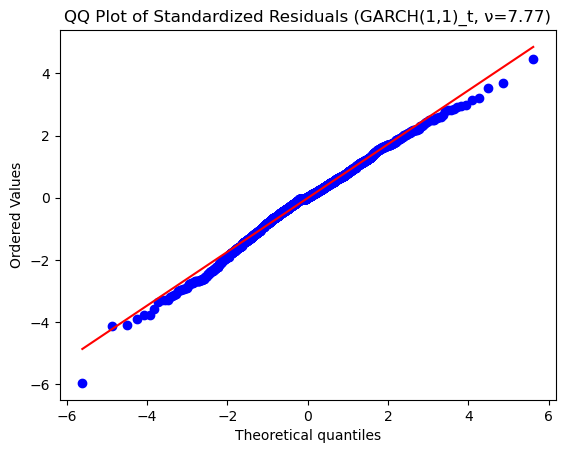

In [123]:
# 標準化残差 a_t/σ_t　を計算
garch_t_res = arch_models['GARCH(1,1)_t']
std_resid_t = garch_t_res.resid / garch_t_res.conditional_volatility

# Ljung-Box(標準化残差自体)-> 平均モデルの妥当性再確認
lb_resid_t = acorr_ljungbox(std_resid_t, lags=[12], return_df=True)
print("Ljung-Box on standardized residuals:\n", lb_resid_t)

# Ljung-Box(標準化残差の二乗) -> ARCH効果が消えたか確認
lb_resid_t_sq = acorr_ljungbox( std_resid_t**2, lags=[12], return_df=True)
print("Ljung-Box on squared standardized residuals:\n", lb_resid_t_sq)

# 歪度・尖度・QQプロット ->　分布仮定の妥当性確認
print(f"歪度: {stats.skew(std_resid_t):.4f}")
print(f"尖度: {stats.kurtosis(std_resid_t, fisher=False):.4f}")

print(garch_t_res.params)

nu = garch_t_res.params['nu']

stats.probplot(std_resid_t, dist=stats.t, sparams=(nu,),plot=plt)
plt.title(f"QQ Plot of Standardized Residuals (GARCH(1,1)_t, ν={nu:.2f})")
plt.show()

平均方程式・ボラティリティ方程式の診断は、§3.4と同様に良好である。分布についても、尖度$4.59$は、自由度$\nu=7.77$のStudent-t分布の理論尖度
$$\frac{6}{\nu-4}+3\Big|_{\nu=7.77}\approx4.59$$
とほぼ完全に一致しており、分布の仮定が適切に修正されたことが確認できる。

QQプロット(下図、Student-t分布、$\nu=7.77$を基準)においても、§3.4で見られた正規分布基準での両端の逸脱が解消され、データがほぼ全域にわたって理論直線に沿っていることが視覚的に確認できる。

**結論**:GARCH(1,1)、誤差項の分布にStudent-t分布(自由度$\hat\nu=7.77$)を用いたモデルは、平均構造・ボラティリティ構造・分布の仮定のいずれにおいても診断上の問題を残さない。本Notebookでは、これを最終モデルとして採用する。

# §4 結論

本Notebookでは、iShares JPX-Nikkei 400 ETF(1364.T)の対数リターンを対象に、
ボラティリティ推定の統計的手法を比較した。

§2では、対数リターンが幾何ブラウン運動(GBM)に従うと仮定し、ドリフト$\mu$と
ボラティリティ$\sigma$を最尤推定した。しかし、この定式化はドリフト・ボラティリティ
がともに時間を通じて一定であることを前提としており、実際の株価データに見られる
ボラティリティクラスタリングを捉えることができない。

§3では、Tsay (2005)の分析手順に従い、この点を実証的に検証した。ACF分析および
Ljung-Box検定の結果、対数リターン$r_t$自体には有意な系列相関が見られない一方、
その二乗$r_t^2$には強い自己相関が存在することが確認された。この結果は、
「リターンは無相関だが独立ではない」というTsayの指摘と整合的であり、平均方程式
$\mu_t=\phi_0$を定数のまま維持しつつ、ボラティリティ$\sigma_t^2$のみを時間変化
させるARCH/GARCH型のモデルを導入する根拠となった。

EngleのLM検定により強いARCH効果が確認された後、ARCH(m)モデル(m=1〜20)、
GARCH(1,1)、EGARCH(1,1)を比較した。GARCH(1,1)は、わずか3パラメータで、
10〜21パラメータを要するARCH(m)モデル群をAIC・BICともに上回り、
Bollerslev (1986)が指摘する「GARCHはARCHより倹約的にボラティリティの依存構造
を捉えられる」という主張を実証的に裏付けた。

さらに、GARCH(1,1)-normalの標準化残差を診断したところ、平均・ボラティリティ
構造は妥当であったものの、正規分布の仮定には厚い裾(尖度4.50)という問題が
残っていた。誤差項の分布をStudent-t分布に変更したところ、BICは約100ポイント
改善し、標準化残差の尖度(4.59)は理論値($6/(\nu-4)+3\approx4.59$、
$\hat\nu=7.77$)とほぼ完全に一致した。歪みStudent-t分布との比較では、
歪みパラメータの追加による説明力の向上は見られず、対称なStudent-t分布で
十分であることが確認された。

以上より、**GARCH(1,1)、誤差項の分布にStudent-t分布(自由度$\hat\nu\approx7.77$)
を用いたモデル**が、平均構造・ボラティリティ構造・分布の仮定のいずれにおいても
診断上の問題を残さない、本Notebookにおける最終モデルである。

### 今後の課題

- インプライドボラティリティ(オプション価格由来)との比較、およびボラティリティリスクプレミアムの検証
- パラメトリックVaR・ヒストリカルVaRへの応用
- GJR-GARCH等、レバレッジ効果をより明示的に捉えるモデルとの比較

# Appendix A - 数理統計学の諸定理
Appendix B以降で今までのコードの数理的背景を説明するために用いられる諸定理をまとめる。
### A.1 マルチンゲール差分列の中心極限定理
定義: 確率変数${W_t}$が、あるフィルとレーション$\{\mathcal{F}_t\}$に関してマルチンゲール差分列であるとは
$$E[W_t|\mathcal{F}_{t-1}]=0  \text{ almost surely}$$
を満たすことをいう。

定理: ${W_t}$がマルチンゲール差分列で、$\text{Var}(W_t) = \sigma_W^2$(一定)、かつ正則条件(有限4次モーメント等）を満たすとき
$$\frac{1}{\sqrt{T}}\sum_{t=1}^{T}W_t \xrightarrow{d} N(0, \sigma_W^2)$$
### A.2 Slutskyの定理
定理: $X_T \xrightarrow{d} X$かつ$Y_T \xrightarrow{p} c$($c$は定数)であるとき
$$X_t + Y_T \xrightarrow{d} X + c,\quad X_T \cdot Y_T \xrightarrow{d} cX, \quad X_T/Y_T \xrightarrow{d} X/c \quad (c\neq 0)$$
### A.3 Cramer-Woldの定理
定理: 確率ベクトル列$X_T = (X_{T,1}, \ldots, X_{T, m})'$に対して、
$$X_T \xrightarrow{d} X \quad \Longleftrightarrow \quad \text{任意の}c=(C_1, \ldots, c_m)' \in \mathbb{R}^m \text{ に対して} c' X_T \rightarrow c' X$$
### A.4 連続写像定理
定理: $X_T \xrightarrow{d} X$であり、$g(\cdot)$が($X$の台の上で)連続な関数である時、
$$g(X_T) \xrightarrow{d} g(X)$$

# Appendix B - §2の理論的背景
1. 幾何ブラウン運動(GBM)

   確率過程$\{S_t\}_{t \geq 0}$が幾何ブラウン運動に従うとは、以下のSDEを満たすことをいう
   $$dS_t = \mu S_t dt + \sigma S_t dW_t, \quad S_0 > 0$$

   $f(x) = \log (x)$とすると、$f'(x) = \frac{1}{x}, \quad f''(x) = - \frac{1}{x^2}$と伊藤の補題から
   $$df(S(t)) = f'(S(t))dS_t + \frac{1}{2}f''(S(t))dS_t dS_t = (\mu - \frac{1}{2}\sigma^2)dt + \sigma dW_t$$
   上式を0からtまで積分して以下を得る
   $$S(t) = S(0)\exp\left\{\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W_t\right\}$$

3. 対数リターンの定義とその分布

   対数リターンを次式で定義する
   $$\text{対数リターン} = \log\frac{S_{t + \Delta t}}{S_t}$$
   すると、
   $$\log\frac{S_{t + \Delta t}}{S_t} = \left\{\left(\mu - \frac{1}{2}\sigma^2)\Delta t + \sigma(W_{t + \Delta t} - W_t\right)\right\}$$
   で、$(W_{t + \Delta t} - W_t) \sim N(0, \Delta t)$(独立増分性）より、
   $$\log \frac{S_{t + \Delta t}}{S_t} \sim N\left((\mu - \frac{1}{2}\sigma^2)\Delta t, \sigma^2 \Delta t\right)$$

5. MLEによるパラメータの推測

   観測データを$S_{t_0}, S_{t_1}, \ldots, _{t_n}$、対数リターンを$X_i = \log \frac{S_{t_i}}{S_{t_{i-1}}}$、$\Delta t_{i} = t_i - t_{i - 1}$とする。
   各$X_i$は独立に$N\left((\mu - \frac{1}{2}\sigma^2)\Delta t, \sigma^2 \Delta t\right)$に従うので、対数尤度関数は
   $$l(\mu, \sigma^2) = -\frac{1}{2}\sum_{i=1}^{n} \log(2 \pi \sigma^2 \Delta t_i) -  \frac{1}{2}\sum_{i=1}^{n}\frac{(X_i - (\mu = \frac{1}{2}\sigma^2)\Delta t_i)^2}{\sigma^2 \Delta t_i}$$
   よって、$\mu, \sigma^2, \nu(=\mu - \frac{1}{2}\sigma^2)$の最尤推定量を$\hat{\mu}, \hat{\sigma}^2, \hat{\nu}$とすると
   $$\hat{\nu} = \frac{\sum_{i=1}^{n} X_i}{\sum_{i=1}^{n} \Delta t_i}$$
   $$\hat{\mu} = \hat{\nu} + \frac{1}{2}\hat{\sigma^2}$$
   $$\hat{\sigma^2} = \frac{1}{n}\sum_{i=1}^{n}\frac{(X_i - (\mu – \frac{1}{2}\sigma^2) \Delta t_i)^2}{\Delta t_i}$$

6. Jensen's Inequalityによる期待値と中央値の乖離

   $S_t = S_0 \exp \left[(\mu - \frac{1}{2}\sigma^2)t + \sigma W_t\right]$に対して、
   $$\text{median}(S_t) = S_0 e^{(\mu - \frac{1}{2}\sigma^2)t} < \mathbb{E}[S_t] = S_0 e^{\mu t}$$
   中央値: $W_t \sim N(0, t)$の中央値は$0$であり、$x \mapsto e^x$は単調増加関数より、単調変換は中央値を保存する。したがって、

   $$\text{median}(S_t) = S_0 \exp\left[(\mu - \frac{1}{2}\sigma^2)t + \sigma \cdot \text{median}(W_t)\right] = S_0 e^{(\mu - \frac{1}{2}\sigma^2)t}$$

   期待値: 対数正規分布のモーメント母関数を用いる。$\sigma W_t \sim N(0, \sigma^2t)$より
   $$\mathbb{E}\left[e^{\sigma W_t}\right] = \exp\left(\frac{1}{2}\sigma^2 t\right)$$
   したがって、
   $$\mathbb{E}[S_t] = S_0 e^{(\mu - \frac{1}{2}\sigma^2)t} \cdot \mathbb{E}\left[e^{\sigma W_t}\right] = S_0 e^{\mu t}$$

   Jensen's Inequalityによる別解釈: $x \mapsto e^x$は凸関数なので、Jensen's Inequalityにより、$\mathbb{E}[e^{\sigma W_t}] \geq e^{\mathbb{E}[\sigma W_t]} = e^0 = 1$. 統合は$W_t$が定数の場合のみ成り立つため、$\sigma > 0$である限り厳密な不等号が成り立つ。

# Appendix C - ARCHモデルとGARCHモデルの数理的背景
Appendix Cでは、§3で用いたARCH・GARCHモデルの定義・性質・予測に関する数理的背景をまとめる。証明はTsay,R.S.(2005). Analysis of Financial Time Series, Chapter 3に基づく。
### C.1 ARCH(m)モデル
**C.1.1 定義**

対数リターン系列$r_t$に対して、$a_t = r_t - \mu_t$を残差とする。$a_t$がARCH(m)モデルに従うとは、
$$a_t = \sigma_t \epsilon_t, \quad \sigma_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \cdots + \alpha_m a_{t-m}^2$$
を満たすことをいう。ここで$\{\epsilon_t\}$は、平均0、分散1のiid列であり、$\alpha_0 > 0, \alpha_i \geq 0 (i > 0)$である。

**C.1.2 性質**

以下、議論の単純化のため、m=1の場合を中心に示す。

**無条件平均**
$$E[a_t] = E[E[a_t|\mathcal{F}_{t -1}]] = E[\sigma_t E[\epsilon_t]] = 0$$

**無条件分散** 
$$\text{Var}(a_t) = E[a_t^2] = E[E[a_t^2|\mathcal{F}_{t-1}]] = E[\alpha_0 + \alpha_1 a_{t-1}^2] = \alpha_0 + \alpha_1 E[a_{t-1}^2]$$
$a_t$が定常であることから、$\text{Var}(a_t) = \text{Var}(a_{t-1}) = E[a_{t-1}^2]$が成り立つので、これを代入して、
$$\text{Var}(a_t) = \alpha_0 + \alpha_1 \text{Var}(a_t)$$
が得られ、これを解いて、
$$\text{Var}(a_t) = \frac{\alpha_0}{1 - \alpha_1}$$
を得る。分散が正であるためには、$0 \leq \alpha_1 < 1$が必要である。

**4次モーメントと尖度**

$\epsilon_t$が標準正規分布に従うと仮定する。正規分布の性質$E[X^4] = 3v^2$, $(X \sim N(0, v))$より、
$$E[a_t^2|\mathcal{F}_{t-1}] = 3\sigma_t^4 = 3(\alpha_0 + \alpha_1 a_{t-1}^2)^2$$
両辺の無条件期待値を取ると
$$E[a_t^4] = 3[\alpha_0^2 + 2 \alpha_0 \alpha_1 E[a_{t-1}^2] + \alpha_1^2 E[a_{t-1}^4]]$$
$m_4 = E[a_t^4] = E[a_{t-1}^4]$(4次まで定常）と置き、$E[a_{t-1}^2] = \alpha_0/(1 - \alpha_1)$を代入すると
$$m_4 = 3 \alpha_0^2 \cdot \frac{1+\alpha_1}{1 - \alpha_1} + 3\alpha_1^2 m_4$$
これを$m_4$について解くと
$$m_4 = \frac{E[a_t^4]}{[\text{Var}(a_t)]^2} = \frac{3(1 - \alpha_1^2)}{1 - 3\alpha_1^2}$$
$m_4 > 0$であるためには、新たに$0 \leq \alpha_1^2 < 1/3$という制約が必要になる。尖度は、
$$\kappa = \frac{E[a_t^4]}{[\text{Var}(a_t)]^2} = \frac{3(1 - \alpha_1^2)}{1 - 3\alpha_1^2}$$
$\kappa - 3 = \frac{6 \alpha_1^2}{1 - 3\alpha_1^2} \geq 0$($\alpha_1 = 0$の時のみ等号）であるから、$\alpha_1 > 0$である限り、$\kappa > 3$が厳密に成り立つ。すなわち、$\epsilon_t$が正規分布出会っても、ARCH(1)モデルに従う$a_t$の無条件分布は聖子分布より厚い裾(fat tail)を持つ。

**C.1.3 次数の特定**

$\eta_t = a_t^2 - \sigma_t^2$と置くと、ARCH(m)モデルは
$$a_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \cdots + \alpha_m a_{t-m}^2 + \eta_t$$
と、$a_t^2$に関するAR(m)モデルの形に書き直せる（ただし、$\{\eta_t\}$は無相関だがiidではない）。この対応関係により、$a_t^2$のPACFを用いてARCHの次数mを決定できる。

**C.1.4 推定**

観測データ$a_1, \ldots, a_T$の完全な尤度は、
$$f(a_1, \ldots, a_T |\alpha) = \prod_{t=m+1}^{T} f(a_t|\mathcal{F}_{t-1}) \times f(a_1, \ldots, a_m|\alpha)$$
と分解できる。ARCH(m)モデルは「m次のマルコフ性」を持つため$t>m$の部分は簡潔な条件付き分布のせきにかけるが、$t \leq m$の部分はモデルが要求する過去の情報が観測機関の外側にあるため、個別の条件付き分布に分解できない。$f(a_1, \ldots, a_m|\alpha)$の厳密な形は複雑なため、サンプルサイズが大きい場合はこれを無視し、条件付き尤度関数
$$f(a_{m+1}, \ldots, a_T |\alpha, a_1, \ldots, a_m) = \prod_{t=m+1}^{T}\frac{1}{\sqrt{2\pi \sigma_t^2}}\exp\left(-\frac{a_t^2}{2\sigma_t^2}\right)$$
を最大化する。これを条件付き最尤推定という。対数尤度は
$$\mathcal{l}(\alpha) = \sum_{t=m+1}^{T} \left[-\frac{1}{2}\log(2\pi) - \frac{1}{2}\log \sigma_t^2 - \frac{a_t^2}{2\sigma_t^2}\right]$$
$\epsilon_t$に厚い裾を持つ分布(標準化Student-t分布、GED等）を仮定する場合も、尤度関数の$g(\cdot)$（確率密度関数）の部分だけが変わり、$\sigma_t^2$の再帰構造自体は変わらない。

**C.1.5 モデルチェッキング**

モデルが正しく指定されていれば、標準化残差
$$\hat{a_t}=\frac{a_t}{\hat{\sigma}_t}$$
はiid列になるはずである。したがって、
- $\{\hat{a}_t\}$のLjung-Box統計量 $\rightarrow$ 平均方程式の妥当性を検証
- $\{\hat{a}_t^2\}$のLjung-Box統計量 $\rightarrow$ ボラティリティ方程式の妥当性を検証
- 歪度・尖度・QQプロット　$\rightarrow$ 分布の仮定の妥当性を検証

**C.1.6 予測**

ARCH(m)モデルの予測は、AR(m)モデルと同様に再帰的に得られる。予測起点を$h$とすると、1期先予測は
$$\sigma_h^2(1) = \alpha_0 + \alpha_1 a_h^2 + \cdots + \alpha_m a_{h+1-m}^2$$
l期先予測は、未観測の$a_{h+l-i}^2$をその条件付き期待値$\sigma_h^2(l - i)$で置き換えることで
$$\sigma_h^2(l) = \alpha_0 + \sum_{i=1}^{m} \alpha_i \sigma_h^2(l-i), \text{ ただし  }\sigma_h^2(l-i) = a_{h+l-i}^2  \quad (l-i \leq 0)$$
と再帰的に計算される。

### C.2 GARCH(m,s)モデル
**C.2.1 定義**

$a_t = r_t - \mu_t$がGARCH(m,s)モデルに従うとは、
$$a_t = \sigma_t \epsilon_t, \quad \sigma_t^2 = \alpha_0 + \sum_{i=1}^{m} \alpha_i a_{t-i}^2 + \sum_{j=1}^s \beta_j \sigma_{t-j}^2$$
を満たすことをいう。ここで$\alpha_0 > 0, \alpha_i \geq 0, \beta_j \geq 0, \sum_{i=1}^{\max(m, s)}(\alpha_i + \beta_i) < 1$（存在しない添字の係数は0とする）。$s=0$の時ARCH(m)モデルとなる。

**C.2.2 性質**

**$a_t^2$のARMAの適用**

$\eta_t =a_t^2 - \sigma_t^2$と置くと、$\sigma_t^2 = a_t^2 - \eta_t$であり、これをGARCHの定義式に代入して整理すると、
$$a_t^2 = \alpha_0 + \sum_{i=1}^{\max(m,s)} (\alpha_i + \beta_i)a_{t-i}^2 + \eta_t - \sum_{j=1}^{s} \beta_j \eta_{t-j}$$
が得られる。$\eta_t$はマルチンゲール差分列であることが以下のように確認できる。
$$E[\eta_t|\mathcal{F}_{t-1}] = E[a_t^2|\mathcal{F}_{t-1}] - \sigma_t^2 = \sigma_t^2 - \sigma_t^2 = 0$$
これより$E[\eta_t] = 0$、かつ$j \geq 1$について、$\eta_{t-j}$が$\mathcal{F}_{t-1}$可測であることから、$\text{Cov}(\eta_t, \eta_{t-j}) = E[\eta_{t-j}E[\eta_t|\mathcal{F}_{t-1}]] = 0$となる。ただし$\{\eta_t\}$は一般にiidではない(条件付き分散が時間変化するため）。

すなわち、GARCH(m,s)モデルは、$a_t^2$系列に対してARMA(max(m,s),s)モデルを適用したものと解釈できる。ARMAモデルの無条件平均の公式を用いると、無条件分散は、
$$E[a_t^2] = \frac{\alpha_0}{1 - \sum_{i=1}^{\max(m,s)} (\alpha_i + \beta_i)}$$

**4次モーメントと尖度(GARCH(1,1)の場合)**

$S_4 = E[\sigma_t^4]$と置く。$a_t|\mathcal{F}_{t-1} \sim N(0, \sigma_t^2)$より、$E[a_t^4] = 3E[\sigma_t^4] = 3S_4$・また$a_{t-1}= \sigma_{t-1} \epsilon_{t-1}$が$\sigma_{t-1}$と独立であることから、
$$E[a_{t-1}^2 \sigma_{t-1}^2) = E[\sigma_{t-1}^4]E[\epsilon_{t-1}^2] = S_4$$
$\sigma_t^2 = \alpha_0 + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2$を二乗し、両辺の無条件期待値を取り、定常性と上記の関係を用いて整理すると
$$S_4[1 - (\alpha_1 + \beta_1)^2 - 2 \alpha_1^2] = \alpha_0^2 + 2\alpha_0 (\alpha_1 + \beta_1)v, \quad v=\text{Var}(a_t) = \frac{\alpha_0}{1 - \alpha_1 - \beta_1}$$
これを解くと、
$$E[a_t^4] = 3S_4 = \frac{3\alpha_0^2(1 + \alpha_1  + \beta_1)}{(1 - \alpha_1 - \beta_1)[1 - (\alpha_1 + \beta_1)^2 - 2 \alpha_1^2]}$$
($\beta_1 = 0$とすればARCH(1)の結果と一致することが確認できる)。尖度は
$$\kappa = \frac{E[a_t^4]}{[E[a_t^2]]^2} = \frac{3[1 - (\alpha_1 + \beta_1)^2}{1 - (\alpha_1 + \beta_1)^2 - 2\alpha_1^2}$$
$\kappa - 3 = \frac{6\alpha_1^2}{1- (\alpha_1 + \beta_1)^2 - 2\alpha_1^2} \geq 0$であり、$1 - 2\alpha_1^2 - (\alpha_1 + \beta_1)^2>0$の条件のもとで、$\alpha_1 > 0$なら$\kappa > 3$。ARCH(1)と同様、GARCH(1,1)も無条件に正規分布より厚い裾を持つ。


**C.2.3 予測**

GARCH(1,1)モデルにおいて、$a_t^2 = \sigma_t^2 \epsilon_t^2$を用いてボラティリティホイ定式を
$$\sigma_{t+1}^2 = \alpha_0 + (\alpha_1 + \beta_1) \sigma_t^2 + \alpha_1 \sigma_t^2 (\epsilon_t^2 - 1)$$
と書き直し、$E[\epsilon_t^2 - 1|\mathcal{F}_t] = 0$を用いると、予測起点$h$から$l$期先の予測は、
$$\sigma_h^2(l) = \alpha_0 + (\alpha_1 + \beta_1) \sigma_h^2 (l-1), \quad l>1$$
という、ARMA(1,1）型の再起式に従う。これを繰り返し代入すると、
$$\sigma_h^2(l) = \frac{\alpha_0[1 - (\alpha_1 + \beta_1)^{l-1}]}{1 - \alpha_1 - \beta_1} + (\alpha_1 + \beta_1)^{l-1}\sigma_h^2(1)$$
$\alpha_1 + \beta_1 < 1$の時、$l \to \infty$で、
$$\sigma_h^2(l) \to \frac{\alpha_0}{1 - \alpha_1 beta_1} = \text{Var}(a_t)$$
に収束する。すなわち、GARCH(1,1)の長期先のボラティリティ予測は、無条件分散に収束する。

# Appendix D - Ljung-Box統計量
### B.1: Ljung-Box統計量
1. 動機:

   「ラグ１からラグmまで、全部の相関がゼロと言えるか」を一つの検定でまとめて判定したい
3. Box-Pierce統計量
   
   $$\text{Box-Pierce統計量} = Q^*(m) = T\sum_{l=1}^{m}\hat{\rho}_l^2$$
   $\hat{\rho}_l$はラグ$l$の標本自己相関、$T$はサンプルサイズ。帰無仮説$H_0 : \rho_1 = \cdots = \rho_m = 0$の元で、$Q^*(m)$は漸近的に自由度mのカイ二乗分布に従う。
5. Ljung-Box統計量
   
   Box-Pierce統計量は、サンプルサイズ$T$が小さいと、実際のカイ二乗分布への近似が悪い。この近似を改善したバージョン。
   $$Q(m) = T(T+2)\sum_{l=1}^{m}\frac{\hat{\rho}^2}{T-l}$$
   帰無仮説. Boc-Pierceと同じく, $H_0 : \rho_1 = \cdots = \rho_m = 0$.
   
   漸近分布. $H_0$の元で、
   $$Q(m) \xrightarrow{d} \mathcal{X}_m^2 \tag{*}$$
7.  判定

    $Q(m) > \mathcal{X}_m^2(\alpha)$(有意水準$\alpha$の上側$100(1 - \alpha)$パーセンタイル)なら、帰無仮説を棄却し、「ラグ$1~m$のどこかに、有意な自己相関があると結論づける.
    
9.  McLeod-Li検定への応用

    $Q(m)$統計量を$r_t$そのものでなく$a_t^2$(二乗残差)に適用。

    帰無仮説. $a_t^2$系列の、ラグ$1~m$の自己相関がゼロ = ARCH効果がない

###
### B.2 (*)の証明
### 定理
${r_t}$を平均$0$, 分散$\sigma^2$, 有限4次モーメントを持つiid過程(ホワイトノイズ)とする。標本自己相関を
$$\hat{\rho}_l = \frac{\hat{\gamma}_l}{\hat{\gamma}_0}, \hat{\gamma}_l = \frac{1}{T}\sum_{t=l+1}^{T}r_t r_{t-l}, \hat{\gamma}_0 = \frac{1}{T}\sum_{t=1}^{T}r_t^2$$
とする。この時、$T \xrightarrow{d} \infty$で
$$Q(m) \approx Q^*(m) = T\sum_{l=1}^{m}\hat{\rho}_l^2 \xrightarrow{d} \mathcal{X}_m^2$$
### 証明
**Step.1: 標本自己共分散の漸近正規性**

補題: ${r_t}$がiid, $E[r_t] = 0, E[r_t^2] = \sigma^2, E[r_t^4] < \infty$の時、
$$\sqrt{T}\hat{\gamma}_l \xrightarrow{d} N(0, \sigma^4) \quad (l\geq 1 \text{ を固定})$$
 
証明: $\sqrt{T}\hat{\gamma}_l = \frac{1}{T}\sum_{t=l+1}^{T} r_t r_{t-l}$とおく。$W_t = r_t r_{t-l}$とすると、${r_t}$が生成する情報の列に関してマルチンゲール差分列になっている。実際、
$$E[W_t|r_{t-1}, r_{t-2}, \ldots] = E[r_t|r_{t-1}, \ldots]\cdot r_{t-l} = E[r_t] \cdot r_{t-l} = 0$$
また、
$$\text{Var}(W_t) = E[r_t^2 r_{t-l}^2] = E[r_t^2]E[r_{t-l}^2] = \sigma^4$$
martingale CLTを適用すると、
$$\frac{1}{\sqrt{T}}\sum_{t=l+1}^{T}W_t \xrightarrow{d} N(0, \sigma^4) \quad \blacksquare$$

**Step.2: 複数ラグの同時漸近正規性(Bartlettの公式)**

補題: ホワイトノイズの元で、異なるラグ$l \neq k$の$\hat{\gamma}_l, \hat{\gamma}_k$は漸近的に無相関になる。すなわち
$$\text{Cov}(\sqrt{T}\hat{\gamma}_l, \sqrt{T}\hat{\gamma}_k) \rightarrow 0 \quad (l\neq K)$$

証明の概略: $\text{Cov}\left(\frac{1}{\sqrt{T}}\sum_t r_t r_{t-l}, \frac{1}{\sqrt{T}}\sum_s r_s r_{s-k}\right)$を展開すると、$E[r_t t_{t-l} r_s r_{s-k}]$の形の項が現れる。iid性・4次モーメントの有限性のもとで、$t \neq s$のクロス項はほとんど全て0になり、生き残る項も$T \rightarrow \infty$で消える。したがって、共分散は漸近的に$0$に収束する。$\blacksquare$

**Step3: $\hat{\gamma}_0$の一致性と、比への変換**

大数の法則より、
$$\hat{\gamma}_0 \xrightarrow{p} \sigma^2$$
Slutskyの定理を使うと、
$$\sqrt{T} \hat{\rho}_l = \sqrt{T}\frac{\hat{\gamma}_l}{\hat{\gamma}_0} = \frac{\sqrt{T}\hat{\gamma}_l}{\hat{\gamma}_0} \xrightarrow{d} \frac{N(0, \sigma^4)}{\sigma^2} = N(0, 1)$$

**Step4: 多変量への拡張(Cramer-Woldの方法)**

任意の実数$c_1, \ldots, c_m$に対して、線型結合$\sum_l c_l \sqrt{T}\hat{\gamma}_l$が正規分布に収束することを示せば、ベクトル全体の多変量正規収束が言える。この線型結合にマルチンゲールCLTを適用し、異なるラグ間の漸近無相関）を組み合わせると、
$$\sqrt{T}(\hat{\rho}_1, \ldots, \hat{\rho}_m)' \xrightarrow{d} N(0, I_m)$$

**Step5: 連続写像定理によるカイ二乗収束**
カイ二乗分布の定義: $Z=(Z_1, \ldots, Z_m)' \sim N(0, I_m)$の時、$||Z||^2=\sum_{l=1}^{m} Z_l^2$は定義により、自由度$m$のカイ二乗分布に従う

連続写像定理により、
$$Q^*(m) = T\sum_{l=1}^{m} \hat{\rho}_l^2 = ||\sqrt{T}(\hat{\rho}_1, \ldots, \hat{\rho}_m)'||^2 \xrightarrow{d} \mathcal{X}_m^2$$

**Step6: Ljung-Box補正

$$Q(m) - Q^*(m) = T(T+2)\sum_{l=1}^{m} \frac{\hat{\rho}_l^2}{T - l} - T \sum_{l=1}^{m}\hat{\rho}_l^2 = \sum_{l=1}^{m}\hat{\rho}_l^2 \left[\frac{T(T + 2)}{T - l} - T\right]$$
各$l$(固定)について、$\frac{T(T+2)}{T-l} - T = T \cdot \frac{(T+2) - (T - l)}{T - l} = T \cdot \frac{l+2}{T - l} = O(1)(T \rightarrow \infty$で有限値に収束)。一方$\hat{\rho}_l^2 =O_p(1/T)$。したがって、
$$Q(m) - Q^*(m) = \sum_l O_p(1/T)\cdot O(1) = O_p(1/T) \xrightarrow{p} 0$$
Slutskyの定理より、$Q^*(m) \xrightarrow{d} \mathcal{X}_m^2$かつ$Q(m) - Q^*(m) \xrightarrow{p} 0$ならば、
$$Q(m) \xrightarrow{d} \mathcal{X}_m^2 \quad \blacksquare$$
